

# Coding (#1) 26 Feb 2025

## Bayesian Global Optimization for Class AMAT 6000A: Advanced Materials Informatics Spring 2025, HKUST (GZ)

This tutorial introduces the concept and implementation of Bayesian Global Optimization (BGO), designed for solving complex optimization problems, especially in materials informatics. We will walk through an esxample of applying BGO to a real-world dataset, using Python and Jpyter Noebooks.

## Code Example, Data, and Illustrations

The code and illustrations will be demonstrated via Jupyter Notebook, providing step-by-step guidance.

### Preparing for the Class

To run the code examples in this tutorial, ensure you have Python and Jupyter Notebook installed. Below is a comprehensive guide to help you get set up:

#### Step 1: Install Python

If you don’t have Python installed, you can download the latest version from the official Python website:

1. Visit the [official Python download page](https://www.python.org/downloads/).
2. Choose the version suitable for your operating system (Windows, macOS, or Linux).
3. Download the installer and follow the instructions to complete the installation.
   
Ensure you select the option to add Python to your PATH during installation.

#### Step 2: Install Jupyter Notebook

Jupyter Notebook is a powerful tool for running Python code in an interactive environment. To install it, follow these steps:

1. Open a terminal or command prompt.
2. Install Jupyter via pip:
   
   ```bash
   pip install notebook
   ```

3. After the installation is complete, start Jupyter by typing the following in your terminal:

   ```bash
   jupyter notebook
   ```

   This will open the Jupyter Notebook interface in your browser.

#### Step 3: Install Required Python Libraries

You’ll need several Python libraries for this tutorial, such as NumPy, pandas, Scikit-learn, and others. To install them, run:

```bash
pip install numpy pandas scikit-learn matplotlib Bgolearn
```


#### Installation

If you encounter any trouble during installation, don’t worry! A tutorial video is available for reference:

- [YouTube Tutorial: Installation and Setup](https://www.youtube.com/watch?v=WUeBzT43JyY)

In case you still face any issues, the TAs will be available to assist you during the class. 
---





---

### Download Example Data

We’ll work with data that is stored in a zip file called **bgo_one.zip**. This file contains two key datasets:

1. **Training Data**: `train.csv`  
   This CSV file contains the training data.

2. **Virtual Data**: `vs.csv`  
   This CSV file includes the searching condidates.


3. **A SVM model**: `svm_model_target1.joblib`


To download the data:

1. Download the **bgo_one.zip** file from the provided link (ensure the source is reliable).
2. Extract the contents of the zip file to the directory of your code.



---

### Gaussian Process Regression (GPR) Tutorial

**Gaussian Process Regression (GPR)** is widely applied in machine learning, especially for modeling uncertain functions and making predictions about unknown data. We will walk through the theory, implementation, and an example using Python.

### Overview of Gaussian Process Regression

#### What is a Gaussian Process?

A **Gaussian Process (GP)** is a collection of random variables, any finite number of which have a joint Gaussian distribution. In other words, it's a distribution over functions that generalizes the notion of a multivariate normal distribution to infinite dimensions.

A GP can be used to define a distribution over possible functions f(x), where the function values at different points in the input space (i.e., ( x )) are correlated. This correlation is captured using a **covariance function** (also known as the kernel).

The key advantage of using GPs in regression tasks is that they not only provide predictions but also quantify uncertainty, which is useful in many real-world applications.



## Implementing GPR in Python

let’s move on to the Python implementation using the `scikit-learn` library.

### 1. Install Required Libraries

```bash
pip install numpy matplotlib scikit-learn
```

### 2. Code Implementation

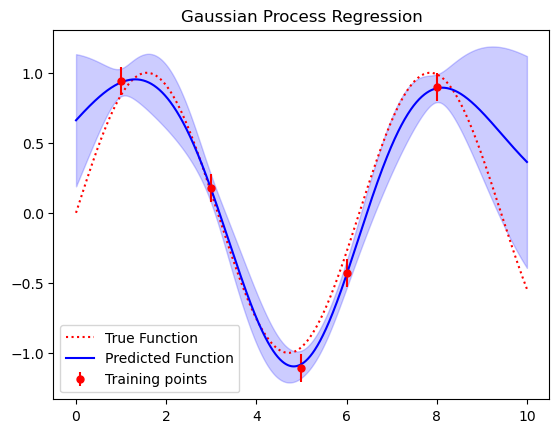

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C

# Generate synthetic data (for example, y = sin(x) with added noise)
# (Experimental function)
def true_function(x):
    return np.sin(x)

# Define the training data (experimental data with labels)
X_train = np.array([1, 3, 5, 6, 8]).reshape(-1, 1)
y_train = true_function(X_train).ravel() + np.random.normal(0, 0.1, X_train.shape[0]) # Random noise from experimental obervations

# Define the kernel: ConstantKernel * RBF
kernel = C(1.0, (1e-4, 1e1)) * RBF(1.0, (1e-4, 1e1))

# Create the GaussianProcessRegressor object
gp = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=10, alpha=1e-2)

# Fit to the training data
gp.fit(X_train, y_train)

# Generate test data points to predict (Protential condidates)
X_test = np.linspace(0, 10, 1000).reshape(-1, 1)

# Predict using the trained model
# (Derive the evaluation for each potential candidate)
y_pred, sigma = gp.predict(X_test, return_std=True)

# Plotting the results
plt.figure()
plt.plot(X_test, true_function(X_test), 'r:', label='True Function')
plt.errorbar(X_train, y_train, 0.1, fmt='r.', markersize=10, label='Training points')
plt.plot(X_test, y_pred, 'b-', label='Predicted Function')
plt.fill_between(X_test.ravel(), y_pred - sigma, y_pred + sigma, alpha=0.2, color='blue')
plt.title("Gaussian Process Regression")
plt.legend(loc='best')
plt.show()

## Use GPR to make predictions on your data


## Explanation of the Code:

- **Kernel Definition**: We define a kernel as the product of a **Constant Kernel** (to control the vertical variation of the function) and an **RBF Kernel** (to control the smoothness of the function).
  
- **Training Data**: We generate some synthetic data (sin(x) function with added Gaussian noise).

- **Model Fitting**: The `GaussianProcessRegressor` from `scikit-learn` is used to fit the GP model to the training data.

- **Prediction**: Once the model is trained, we use it to predict values on a dense grid of test points, and also return the standard deviation (uncertainty) of the predictions.

- **Plotting**: We plot the true function, the training data points, the predicted mean, and the uncertainty (confidence interval) of the predictions.

[reference](https://scikit-learn.org/stable/modules/generated/sklearn.gaussian_process.GaussianProcessRegressor.html) 
---

## Visualizing the Results

- The red dashed line represents the true function ( y = sin(x) ).
- The red dots are the noisy training points.
- The blue line shows the predicted mean function.
- The shaded area represents the uncertainty (standard deviation) around the predicted mean.


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C


# Define the training data (experimental data with labels)
X_train = pd.read_csv('train.csv').iloc[:,:-1]
y_train = pd.read_csv('train.csv').iloc[:,-1]

# Define the kernel: ConstantKernel * RBF
kernel = C(1.0, (1e-4, 1e1)) * RBF(1.0, (1e-4, 1e1))

# Create the GaussianProcessRegressor object
gp = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=10, alpha=1e-2)

# Fit to the training data
gp.fit(X_train, y_train)

# Generate test data points to predict (Protential condidates)
X_test = pd.read_csv('vs.csv')

# Predict using the trained model
# (Derive the evaluation for each potential candidate)
y_pred, sigma = gp.predict(X_test, return_std=True)


C:\Users\binja\anaconda3\Lib\site-packages\sklearn\gaussian_process\kernels.py:430: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__constant_value is close to the specified upper bound 10.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


In [4]:
y_pred

array([  0.40969502,   0.51227094,   0.61900072, ..., 116.42905539,
       113.17141274, 106.86631403])

In [5]:
sigma

array([3.16224158, 3.16221852, 3.16218624, ..., 0.23953255, 0.09757132,
       0.09757125])

---

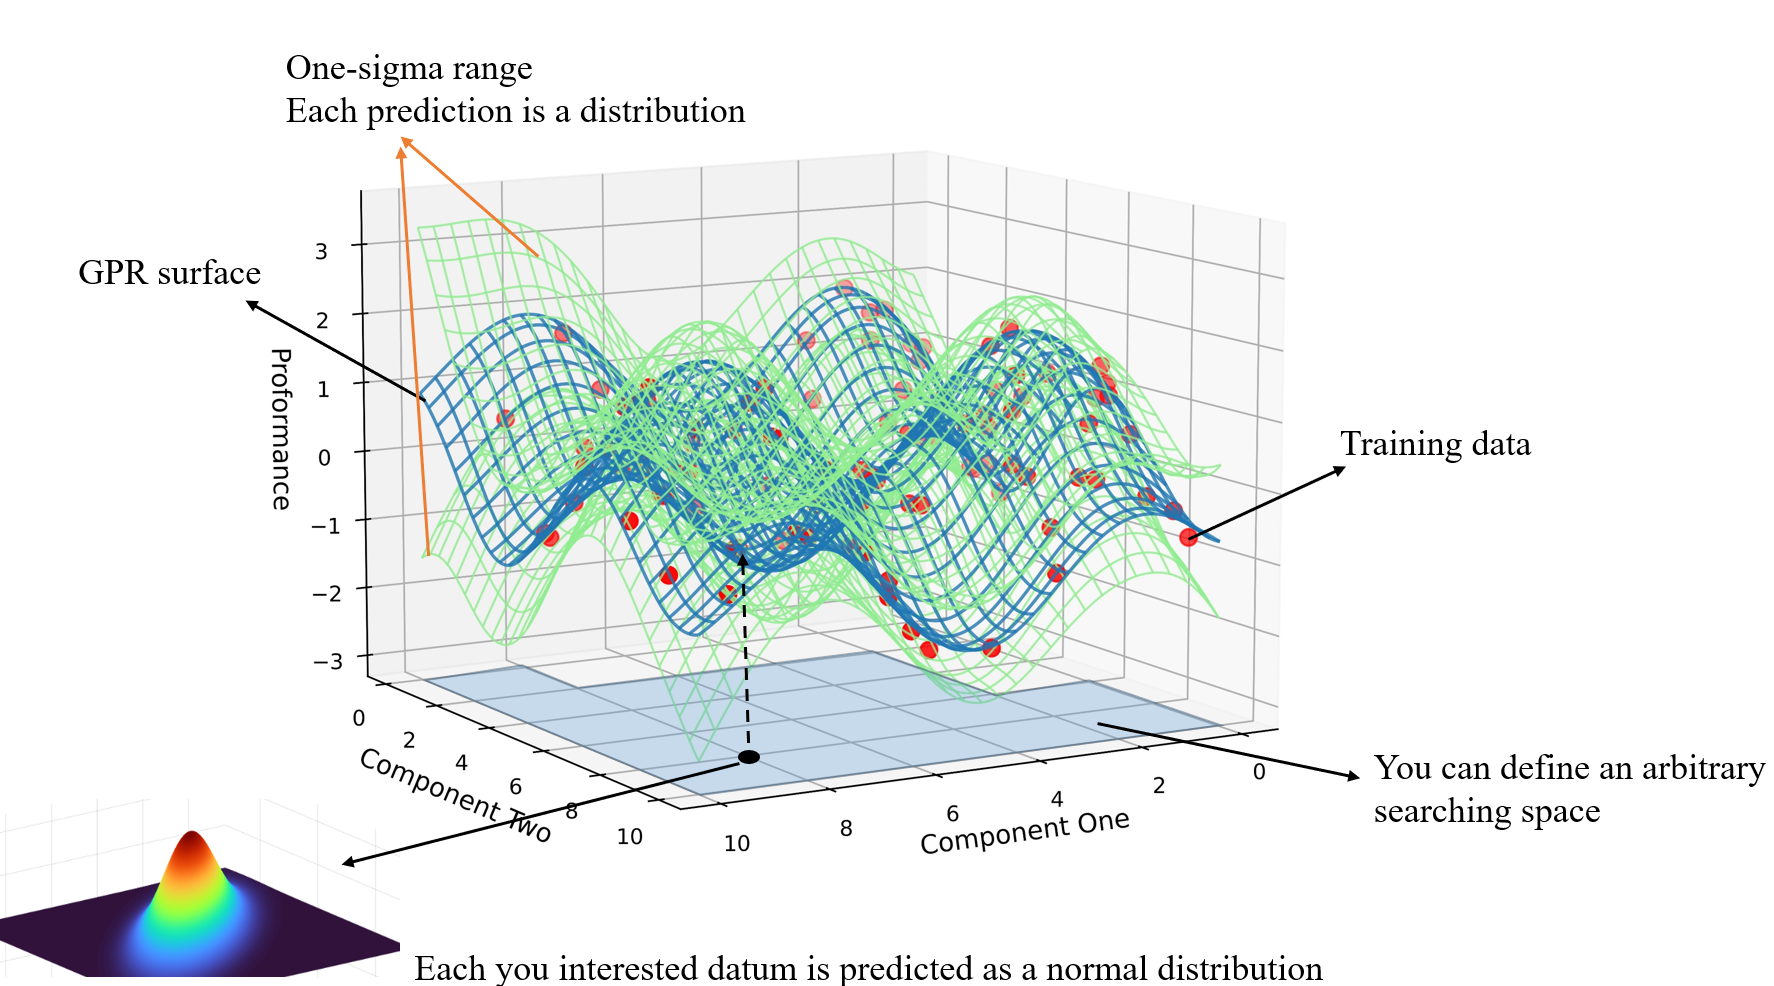



---

### **Utility Function for Ranking Candidates**

The **utility function** ranks all the candidates defined within the search space based on their predicted distributions, rather than directly selecting the one with the maximum or minimum predicted mean. This approach provides a more robust and informed strategy for decision-making during optimization.

---

### **Why Do We Need a Utility Function Instead of Directly Selecting Based on Prediction Mean?**

While it might seem tempting to simply select the candidate with the maximum or minimum predicted mean (i.e., the point where we expect the highest or lowest output value), this strategy has several limitations:

1. **Uncertainty Consideration**: The predicted mean alone does not account for the uncertainty (variance) in the predictions. A point with a high predicted mean might have a large uncertainty, meaning the actual value could be far from the prediction. This could lead to poor decisions when the optimization is exploring regions with high variance.

2. **Exploration vs. Exploitation**: A utility function helps balance **exploration** (searching in areas with high uncertainty) and **exploitation** (focusing on areas where the predicted mean is promising). The maximum or minimum predicted mean strategy would ignore areas with high uncertainty, which could be valuable in improving the model's understanding of the function.

3. **Improving Sample Efficiency**: The utility function (such as **Expected Improvement** or **Probability of Improvement**) takes both the predicted mean and the variance into account to select points where we expect the most significant improvement. This leads to more efficient sampling and faster convergence towards the optimal solution.

4. **Avoiding Local Optima**: Directly selecting based on the predicted mean could lead to premature convergence to suboptimal regions, especially if the model has not been sufficiently trained or if the true function has multiple local minima or maxima. The utility function, on the other hand, encourages exploration of the search space, reducing the risk of falling into a local optimum.

---



### **Using GPR and Utility Functions in BGO**

We have shown how to use **Gaussian Process Regression (GPR)** to make predictions on your data. Once the predictions are made, they are submitted to the **utility function**, which ranks all potential candidates according to their predicted distributions. Based on this ranking, the top candidates are chosen as the next points to evaluate in the optimization process.


It contains four features: Sn, Bi, In, and Ti, and one target variable: T.

In [2]:
# import training data
import pandas as pd
data = pd.read_csv('train.csv')
print(data)

      Sn   Bi   In   Ti       T
0   92.9  3.0  2.5  0.1   64.60
1   92.7  3.0  2.5  0.3   62.59
2   92.5  3.0  2.5  0.5   72.05
3   91.9  3.0  3.5  0.1   66.60
4   91.7  3.0  3.5  0.3   70.29
5   91.5  3.0  3.5  0.5   68.33
6   91.9  4.0  2.5  0.1   77.65
7   91.7  4.0  2.5  0.3   80.49
8   91.5  4.0  2.5  0.5   81.03
9   90.9  4.0  3.5  0.1   78.59
10  90.7  4.0  3.5  0.3   84.98
11  90.5  4.0  3.5  0.5   87.58
12  90.9  5.0  2.5  0.1   87.42
13  90.7  5.0  2.5  0.3   94.48
14  90.5  5.0  2.5  0.5   95.07
15  89.9  5.0  3.5  0.1   92.51
16  89.7  5.0  3.5  0.3   89.85
17  89.5  5.0  3.5  0.5   90.41
18  86.8  5.5  5.5  0.7  106.65
19  86.9  5.5  5.4  0.7  110.56
20  86.9  5.5  5.5  0.6  113.44
21  92.5  2.5  3.4  0.1   65.51
22  92.6  2.5  3.3  0.1   62.67
23  92.4  2.5  3.4  0.2   65.40
24  92.4  1.5  4.5  0.1   74.64
25  92.2  1.5  4.7  0.1   78.49
26  92.4  1.5  4.4  0.2   73.94


It contains data that needs to be predicted, which only includes the features: Sn, Bi, In, and Ti, without the target variable: T

In [3]:
# import vs data
import pandas as pd
vs_data = pd.read_csv('vs.csv')
print(vs_data)

         Sn   Bi   In   Ti
0      95.4  1.5  1.5  0.1
1      95.3  1.5  1.5  0.2
2      95.2  1.5  1.5  0.3
3      95.1  1.5  1.5  0.4
4      95.0  1.5  1.5  0.5
...     ...  ...  ...  ...
11762  87.2  5.5  5.5  0.3
11763  87.1  5.5  5.5  0.4
11764  87.0  5.5  5.5  0.5
11765  86.9  5.5  5.5  0.6
11766  86.8  5.5  5.5  0.7

[11767 rows x 4 columns]


#### step 1 : import your dataset 

In [6]:
import pandas as pd
data = pd.read_csv('train.csv')

vs_data = pd.read_csv('vs.csv')

#### step 2 : build a gpr model

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C

# Define the training data (experimental data with labels)
X_train = data.iloc[:,:-1]
y_train = data.iloc[:,-1]

# Define the kernel: ConstantKernel * RBF
kernel = C(1.0, (1e-4, 1e1)) * RBF(1.0, (1e-4, 1e1))

# Create the GaussianProcessRegressor object
gp = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=10, alpha=1e-2)

# Fit to the training data
gp.fit(X_train, y_train)

# vs_data : Protential condidates)

# Predict using the trained model
# (Derive the evaluation for each potential candidate)
y_pred, sigma = gp.predict(vs_data, return_std=True)


C:\Users\binja\anaconda3\Lib\site-packages\sklearn\gaussian_process\kernels.py:430: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__constant_value is close to the specified upper bound 10.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


#### step 3 : define an utility function, e.g., EI

In [10]:
import numpy as np
from scipy.stats import norm

def expected_improvement(T=None, virtual_samples_mean=None, virtual_samples_std=None, virtual_data=None, measured_response=None, opt_num=1):
    """
    Expected Improvement algorithm.

    :param T: (float, default=None) The preset baseline. If set to None, the maximum value in the training data will be used as the baseline.
    :param virtual_samples_mean: (array-like) The predicted mean values of the virtual samples.
    :param virtual_samples_std: (array-like) The standard deviations of the virtual samples.
    :param virtual_data: (array-like) The virtual sample's dataset.
    :param measured_response: (array-like) The measured responses used for calculating the baseline.
    :param opt_num: (int) The number of points to recommend based on the Expected Improvement.
    
    :return: EI_list (array-like), recommended_x (array-like)
    """
    
    # If baseline T is not set, calculate it from the measured_response
    if isinstance(T, (float, int)):
        cur_optimal_value = T
        print('The baseline is assigned by the user.')
    else:
        print('The baseline is calculated based on the training dataset.')
        cur_optimal_value = np.max(measured_response)
            
    print('Current optimal is:', cur_optimal_value)

    EI_list = []
    for i in range(len(virtual_samples_mean)):
        Var_Z = (virtual_samples_mean[i] - cur_optimal_value) / virtual_samples_std[i]
        EI = (virtual_samples_mean[i] - cur_optimal_value) * norm.cdf(Var_Z) + virtual_samples_std[i] * norm.pdf(Var_Z)

        EI_list.append(EI)
    
    EI_list = np.array(EI_list)
    
    recommended_x = []
    if opt_num == 1:
        EI_opt_index = np.random.choice(np.flatnonzero(EI_list == EI_list.max()))
        print('The next datum recommended by Expected Improvement: \n x = ', virtual_data[EI_opt_index])
        print('The predictions are: \n y = ', virtual_samples_mean[EI_opt_index])
        recommended_x.append(virtual_data[EI_opt_index])
    elif isinstance(opt_num, int):
        EI_opt_index = np.argsort(EI_list)[-opt_num:][::-1]
        for j in range(len(EI_opt_index)):
            print(f'The {j+1}-th datum recommended by Expected Improvement: \n x = ', virtual_data[EI_opt_index[j]])
            print('The predictions are: \n y = ', virtual_samples_mean[EI_opt_index[j]])
            recommended_x.append(virtual_data[EI_opt_index[j]])
    else:
        print('The input parameter opt_num must be an int')

    return EI_list, np.array(recommended_x)


#### step 4 : evaluating all candidates by the defined utility function

In [11]:
virtual_samples_mean = y_pred
virtual_samples_std = sigma
virtual_data = np.array(vs_data)
measured_response = y_train

expected_improvement(
    virtual_samples_mean=virtual_samples_mean,
    virtual_samples_std=virtual_samples_std,
    virtual_data=virtual_data,
    measured_response=measured_response
)

The baseline is calculated based on the training dataset.
Current optimal is: 113.44
The next datum recommended by Expected Improvement: 
 x =  [87.1  5.5  5.4  0.5]
The predictions are: 
 y =  116.88317399665092


(array([3.65681761e-281, 1.15652365e-280, 3.81534449e-280, ...,
        2.98905539e+000, 8.69477066e-005, 0.00000000e+000]),
 array([[87.1,  5.5,  5.4,  0.5]]))

---


### **BGOlearn: Simplifying the Process**

The **BGOlearn** library integrates these functions (GPR, utility function, and ranking) into a unified framework, making it easier to use and more efficient for optimization tasks. Bgolearn has various domestic and international mirrors, including Tsinghua University, Alibaba, Tencent, University of Science and Technology of China, etc., with over [74,000](https://www.pepy.tech/projects/Bgolearn) downloads.

- **Homepage**: [BGOlearn_hp](http://bgolearn.caobin.asia/)
- **Code**: [BGOlearn_code](https://github.com/Bin-Cao/Bgolearn)



In [12]:
import pandas as pd
data = pd.read_csv('train.csv')
vs_data = pd.read_csv('vs.csv')


import Bgolearn.BGOsampling as BGOS
Bgolearn = BGOS.Bgolearn() 

Mymodel = Bgolearn.fit(data_matrix = data.iloc[:,:-1], Measured_response = data.iloc[:,-1], virtual_samples = vs_data,min_search=False)
Mymodel.EI()

 ____                 _                           
| __ )   __ _   ___  | |  ___   __ _  _ __  _ __  
|  _ \  / _` | / _ \ | | / _ \ / _` || '__|| '_ \ 
| |_) || (_| || (_) || ||  __/| (_| || |   | | | |
|____/  \__, | \___/ |_| \___| \__,_||_|   |_| |_|
        |___/                                     

Bgolearn, Bin CAO, HKUST(GZ)
URL : https://github.com/Bin-Cao/Bgolearn and https://bgolearn.netlify.app/
Citation: 
Materials & Design : https://doi.org/10.1016/j.matdes.2024.112921
NPJ Computational Materials : https://doi.org/10.1038/s41524-024-01243-4
Executed on : 2025-02-23 10:47:07  | Have a great day.
The internal model is instantiated with optimized homogenous noise
The baseline is calculated based on the training dataset.
current optimal is : 113.44
The next datum recomended by Expected Improvement : 
 x =  [87.1  5.5  5.5  0.4]
The predictions of Bgolearn are : 
 y =  103.93545425132405


(array([1.01196525e-06, 3.62815136e-07, 3.75460856e-07, ...,
        3.62891429e-01, 3.21302045e-01, 3.50731033e-01]),
 array([[87.1,  5.5,  5.5,  0.4]]))

In [13]:
import Bgolearn.BGOsampling as BGOS
Bgolearn = BGOS.Bgolearn() 
Mymodel = Bgolearn.fit(data_matrix = data.iloc[:,:-1], Measured_response = data.iloc[:,-1], virtual_samples = vs_data,min_search=False)
Mymodel.UCB()

 ____                 _                           
| __ )   __ _   ___  | |  ___   __ _  _ __  _ __  
|  _ \  / _` | / _ \ | | / _ \ / _` || '__|| '_ \ 
| |_) || (_| || (_) || ||  __/| (_| || |   | | | |
|____/  \__, | \___/ |_| \___| \__,_||_|   |_| |_|
        |___/                                     

Bgolearn, Bin CAO, HKUST(GZ)
URL : https://github.com/Bin-Cao/Bgolearn and https://bgolearn.netlify.app/
Citation: 
Materials & Design : https://doi.org/10.1016/j.matdes.2024.112921
NPJ Computational Materials : https://doi.org/10.1038/s41524-024-01243-4
Executed on : 2025-02-23 10:47:14  | Have a great day.
The internal model is instantiated with optimized homogenous noise
The next datum recomended by Upper confidence bound  : 
 x =  [86.8  5.5  5.5  0.7]
The predictions of Bgolearn are : 
 y =  105.92039764709571


(array([ 73.05277886,  72.27454728,  72.38471129, ..., 111.99110471,
        112.05453132, 112.18247858]),
 array([[86.8,  5.5,  5.5,  0.7]]))

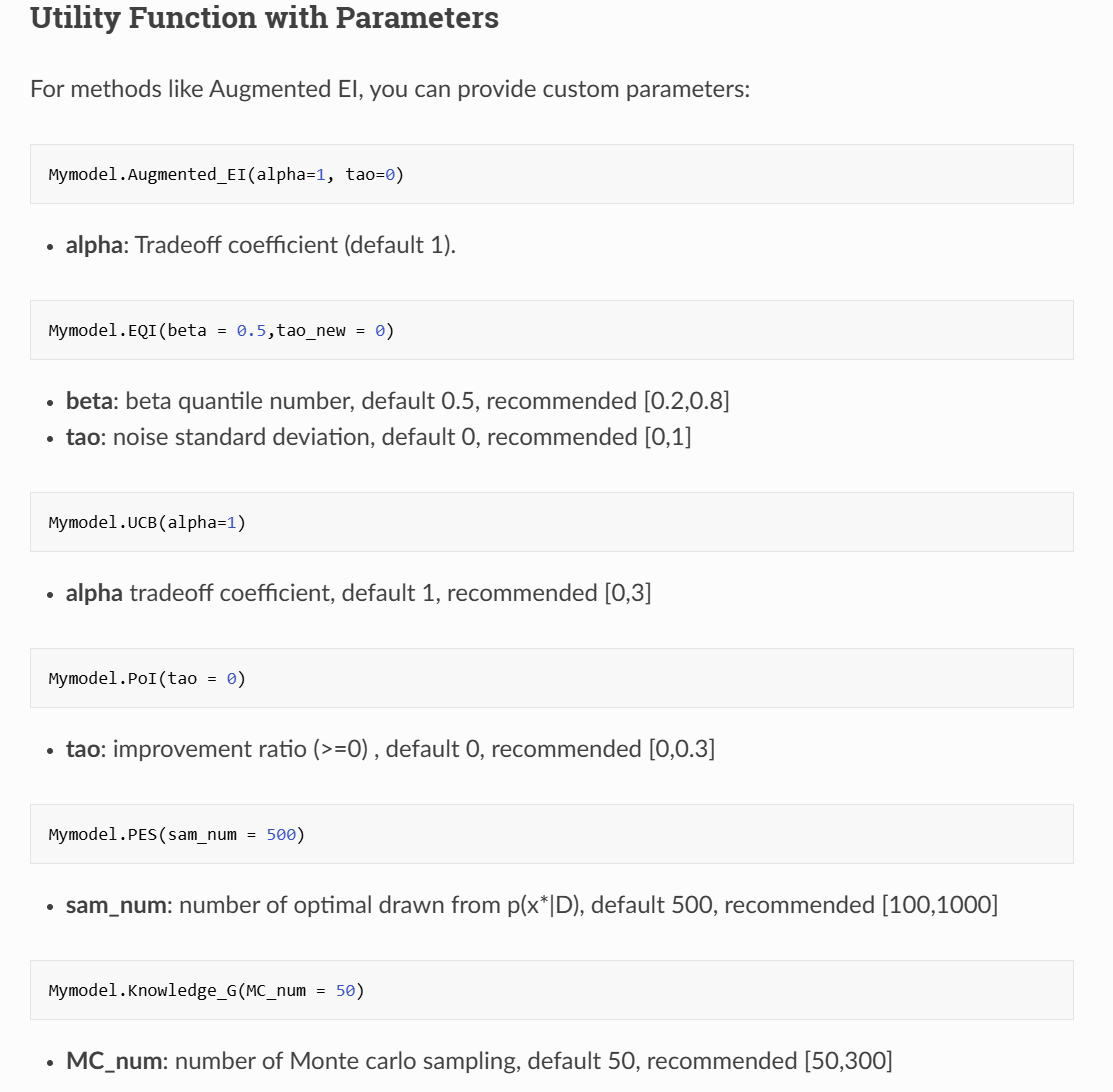


**Documentation**: [https://bgolearn.netlify.app/bgolearn/](https://bgolearn.netlify.app/bgolearn/)

**Chinese Video Tutorial**: [https://www.bilibili.com/video/BV1LTtLeaEZp/?spm_id_from=333.337.search-card.all.click&vd_source=6b9872e6d30ffcbac3baf8965e05bab4](https://www.bilibili.com/video/BV1LTtLeaEZp/?spm_id_from=333.337.search-card.all.click&vd_source=6b9872e6d30ffcbac3baf8965e05bab4)



---

## Copy the recommended data to replace `VS_recommended`. Use the following code to derive the responses `T` for the recommended data. The code below represents an experiment designed to observe the performance of the newly recommended data.


In [14]:
VS_recommended = [87.1,  5.5,  5.5,  0.4]

# evl the properties
#################################################
# Load the trained models
import joblib
import numpy as np
svr_model_1 = joblib.load('svm_model_target1.joblib')

# Input new features (replace with actual feature values)
new_features = np.array(VS_recommended).reshape(1, -1) 

# Make predictions for both targets
prediction_1 = svr_model_1.predict(new_features)

# Output the predicted values
print(f'Predicted value for target T: {prediction_1[0]}')
#################################################

Predicted value for target T: 110.98788442598699


## Use the following code to add the newly recommended data into the training dataset, and name it 'data_add_1'. Alternatively, you can manually add the new data by editing the CSV table.



In [15]:
new_row = np.concatenate([ new_features[0], [prediction_1[0]] ])
data.loc[len(data)] = new_row
data.to_csv('data_add_1.csv', index=False)